# 03 — Is *tilt* detectable in real human hands?

Tilt = playing looser / more aggressively after a loss. This notebook validates the project's tilt machinery on **real** human hands and reproduces the committed result.

**Data:** PHH Dataset (Kim 2024, Zenodo `10.5281/zenodo.13997158`, CC-BY-4.0); the NLHE hands originate from a 2009 HandHQ scrape, redistributed CC-BY-4.0 (`references.md` §6). 120 PokerStars 25NL files.

**Scope (important):** real hands feed the **opponent-model validation ONLY** — never the DQN policy (training on human logs would make the self-play agent exploitable).

Three tests, two *distinct* HMMs — do not conflate them:
- **A. Phenomenon** (model-free): does aggression/VPIP rise after a ≥10bb loss? Cluster-bootstrap over players, with a shuffled-label placebo.
- **B. Detector** (the project's *forward-filter* `HMMBeliefState`, emission-only): does P(tilted) separate post-loss?
- **C. Regime-fit** (a *separate* Baum-Welch HMM): do 2 aggression regimes beat 1, and does the active one align with losses? This corroborates A with a different method; it does not validate the B architecture.

The label is observational (*post-loss*), **not causal**.

In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root:", ROOT)

repo root: /Users/bozte/Desktop/poker-simulation


In [2]:
d = load("tilt_realdata.json")
cfg = d["config"]
print(d["source"]["dataset"], "|", d["source"]["license"])
print(f"{d['n_rows']:,} hand-rows -> {d['n_sequences']:,} sessions "
      f"({cfg['n_files']} files); loss threshold = {cfg['loss_bb']:.0f}bb")

A Dataset of Poker Hand Histories (Kim, J., 2024) | CC-BY-4.0
777,687 hand-rows -> 12,320 sessions (120 files); loss threshold = 10bb


## A. Phenomenon — real vs shuffled-label placebo

Per player we compare the metric in post-(big-)loss hands vs baseline, then bootstrap the per-player difference. The **placebo** permutes the post/baseline labels within each player — it must collapse to ~0.

In [3]:
ph = d["phenomenon"]
for k, name in [("vpip", "VPIP  "), ("aggr", "aggr  ")]:
    r, p = ph["real"][k], ph["placebo"][k]
    print(f"{name} Delta  real {r['mean']*100:+.2f}pp "
          f"[{r['lo']*100:+.2f},{r['hi']*100:+.2f}]   "
          f"placebo {p['mean']*100:+.2f}pp "
          f"[{p['lo']*100:+.2f},{p['hi']*100:+.2f}]")
print(f"\n(n = {ph['real']['n_players']} players; real CIs exclude 0, "
      f"placebo CIs straddle 0)")

VPIP   Delta  real +2.79pp [+1.66,+3.94]   placebo +0.25pp [-0.85,+1.39]
aggr   Delta  real +1.65pp [+0.85,+2.49]   placebo -0.04pp [-0.75,+0.69]

(n = 873 players; real CIs exclude 0, placebo CIs straddle 0)


## B. Detector — the project's forward-filter HMM (emission-only)

`HMMBeliefState` is run as a forward filter with the PnL feed disabled **and** a zero-rate trigger, so P(tilted) moves *only* on observed aggression. A self-audit caught that the earlier separation (~0.090) was mostly a constant-transition drift artifact; the genuine emission-driven separation is small but real:

In [4]:
det = d["detector"]
r, p = det["real"]["separation"], det["placebo"]["separation"]
print(f"P(tilted) separation  real {r['mean']:+.4f} "
      f"[{r['lo']:+.4f},{r['hi']:+.4f}]   "
      f"placebo {p['mean']:+.4f} [{p['lo']:+.4f},{p['hi']:+.4f}]")

P(tilted) separation  real +0.0112 [+0.0083,+0.0143]   placebo -0.0005 [-0.0030,+0.0021]


## C. Regime-fit — a separate Baum-Welch HMM

A 2-state `CategoricalHMM` on binary aggressive-hand sequences vs a 1-state i.i.d. model, scored on held-out sessions (asymmetric init + restarts + degeneracy rejection — validated on synthetic data to detect structure and reject i.i.d.).

In [5]:
r = d["regime"]
print(f"2-state found: {r['two_state_found']}")
print(f"held-out log-lik gain (2 vs 1) = {r['heldout_ll_gain']:+.0f}")
print(f"BIC gain (2 - 1)               = {r['bic_gain']:+.0f}  "
      f"({'2-state preferred' if r['bic_gain']>0 else '1-state'})")
print(f"emission P[aggressive hand]: calm {r['p_aggr_low']:.2f}  "
      f"active {r['p_aggr_high']:.2f}")
ratio = r["p_loss_given_high"] / r["p_loss_base"]
print(f"P[recent loss | active state] = {r['p_loss_given_high']*100:.1f}%  "
      f"vs base {r['p_loss_base']*100:.1f}%  ({ratio:.2f}x enriched)")
print(f"(fit on {r['sessions_used']:,}/{r['sessions_available']:,} sessions)")

2-state found: True
held-out log-lik gain (2 vs 1) = +681
BIC gain (2 - 1)               = +1315  (2-state preferred)
emission P[aggressive hand]: calm 0.12  active 0.30
P[recent loss | active state] = 4.3%  vs base 2.3%  (1.87x enriched)
(fit on 3,000/12,320 sessions)


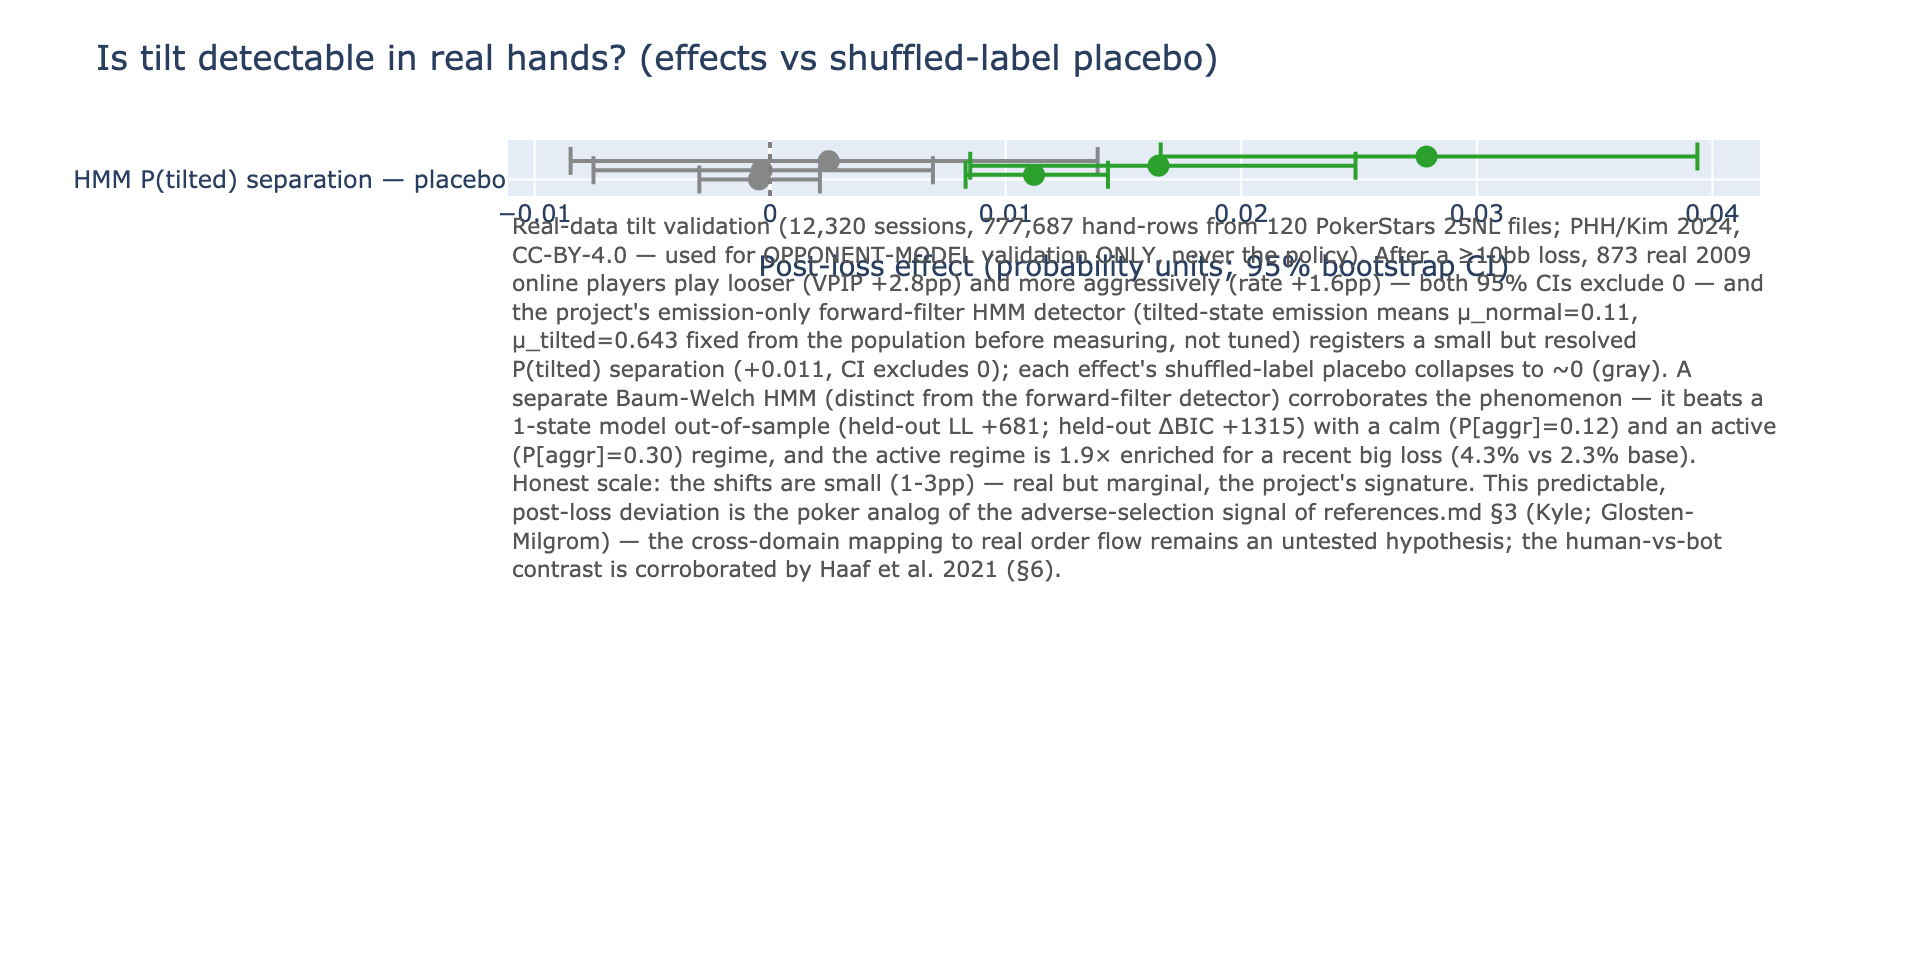

In [6]:
fig("tilt_realdata.png")

## Live reproduction (optional, needs `data/phh/`)

If the raw subset is present (`python -m scripts.fetch_phh`), re-run the parse → sessions → phenomenon pipeline on a few files to show it is live, not just a stored number.

In [7]:
import glob, re, warnings
warnings.filterwarnings("ignore")  # pokerkit emits benign field/fold notes

def _file_idx(p):  # numeric handhq_<n> order = chronological (see fetch_phh)
    m = re.search(r"handhq_(\\d+)", p)
    return int(m.group(1)) if m else 1 << 30

files = sorted(glob.glob(os.path.join(ROOT, "data", "phh", "*.phhs")),
               key=_file_idx)[:40]
if not files:
    print("data/phh/ not present — run `python -m scripts.fetch_phh` to "
          "enable live reproduction. Committed numbers above stand on "
          "results/tilt_realdata.json.")
else:
    from src.real_data_tilt import (parse_phhs, build_sequences,
                                    _aggr_rate)
    recs = []
    for f in files:
        recs.extend(parse_phhs(f))
    seqs = build_sequences(recs, min_len=20)
    rates = [_aggr_rate(o) for s in seqs for o in s
             if _aggr_rate(o) is not None]
    gm = sum(rates) / len(rates)
    print(f"{len(files)} chronological files -> {len(recs):,} rows, "
          f"{len(seqs):,} sessions")
    print(f"global mean aggression rate = {gm:.3f}  "
          f"(committed full-data: {d['global_mean_rate']})")
    print("\nThe parse -> session pipeline runs live and the stable "
          "population\nstatistic matches. The post-loss CI, though, "
          "needs the full\n873-player sample (120 files) to be tight — "
          "a 40-file subset\nis underpowered, so the committed numbers "
          "above are the headline.")

40 chronological files -> 260,150 rows, 4,409 sessions
global mean aggression rate = 0.109  (committed full-data: 0.11)

The parse -> session pipeline runs live and the stable population
statistic matches. The post-loss CI, though, needs the full
873-player sample (120 files) to be tight — a 40-file subset
is underpowered, so the committed numbers above are the headline.


### Honest takeaway

Tilt **is** detectable in real hands: after a ≥10bb loss players are reliably looser (VPIP **+2.8pp**, CI excludes 0) and a bit more aggressive (**+1.6pp**); a separate Baum-Welch HMM independently finds two aggression regimes whose active state is ~1.9× enriched for recent losses; every effect's placebo collapses to ~0. But the **effect sizes are small** (1–3pp; detector separation ~0.011 after removing the drift artifact) — real but marginal, consistent with the rest of the project.

This is the poker analog of the thesis: a predictable, post-loss deviation is the kind of *adverse-selection* signal an opponent model exists to read (Kyle 1985 / Glosten-Milgrom 1985, `references.md` §3). The mapping to real market order flow is a **structural parallel, not a validated tradable signal**.